## 1. Introduction

In [1]:
import os
import re
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss

/Users/ayomideolakulehin/mambaforge/envs/product-retrieval-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =========================================================
# Configuration
# =========================================================
sns.set_theme(style="whitegrid")
SEED = 42
np.random.seed(SEED)

BENCHMARK_DIR = "benchmark"
MODEL_ARTIFACT_DIR = "artifacts"
os.makedirs(MODEL_ARTIFACT_DIR, exist_ok=True)

## 2. Functions

In [ ]:


def to_text(x):
    if isinstance(x, list):
        return " ".join(map(str, x))
    if pd.isna(x):
        return ""
    return str(x)


def word_count(text):
    text = to_text(text).strip()
    return 0 if text == "" else len(text.split())


def char_count(text):
    return len(to_text(text))


def clean_lexical_text(text):
    text = to_text(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def safe_duplicate_count(frame):
    safe = frame.copy()
    for c in safe.columns:
        safe[c] = safe[c].apply(lambda v: json.dumps(v, sort_keys=True) if isinstance(v, (list, dict)) else v)
    return int(safe.duplicated().sum())


def add_stable_doc_id(frame):
    out = frame.reset_index(drop=True).copy()
    if "parent_asin" in out.columns:
        base_ids = out["parent_asin"].fillna("").astype(str).str.strip()
        base_ids = np.where(base_ids == "", "row_" + out.index.astype(str), base_ids)
    else:
        base_ids = "row_" + out.index.astype(str)

    base_ids = pd.Series(base_ids, dtype="string")
    dup_no = base_ids.groupby(base_ids).cumcount()
    out["doc_id"] = np.where(dup_no == 0, base_ids, base_ids + "__dup" + dup_no.astype(str))
    return out

## Data Loading

In [4]:
# Load frozen corpus prepared in product-data-preparation.ipynb
PRODUCTS_CSV = "data/products.csv"

if not os.path.exists(PRODUCTS_CSV):
    raise FileNotFoundError(
        "products.csv not found. Run product-data-preparation.ipynb first to generate it."
    )

df_raw = pd.read_csv(PRODUCTS_CSV)

print("Loaded rows:", len(df_raw))
print("Columns:", len(df_raw.columns))
df_raw[[c for c in ["doc_num", "doc_id", "title", "main_category"] if c in df_raw.columns]].head(3)

Loaded rows: 10000
Columns: 19


,doc_num,doc_id,title,main_category
0,1,B01CUPMQZE-NbrnTP3fAb,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",All Beauty
1,2,B076WQZGPM-nFbmOHnKYa,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,All Beauty
2,3,B000B658RI-XRvj7uff0L,Eye Patch Black Adult with Tie Band (6 Per Pack),All Beauty


## Data Exploration

Potential duplicate rows (safe check): 0
doc_id unique: 10000 / 10000
doc_id nulls: 0
Unique parent_asin groups: 10000
Avg variants per parent_asin: 1.0
title_empty_pct           0.01
description_empty_pct     0.00
features_empty_pct        0.00
combined_lt5_words_pct    0.11
dtype: float64


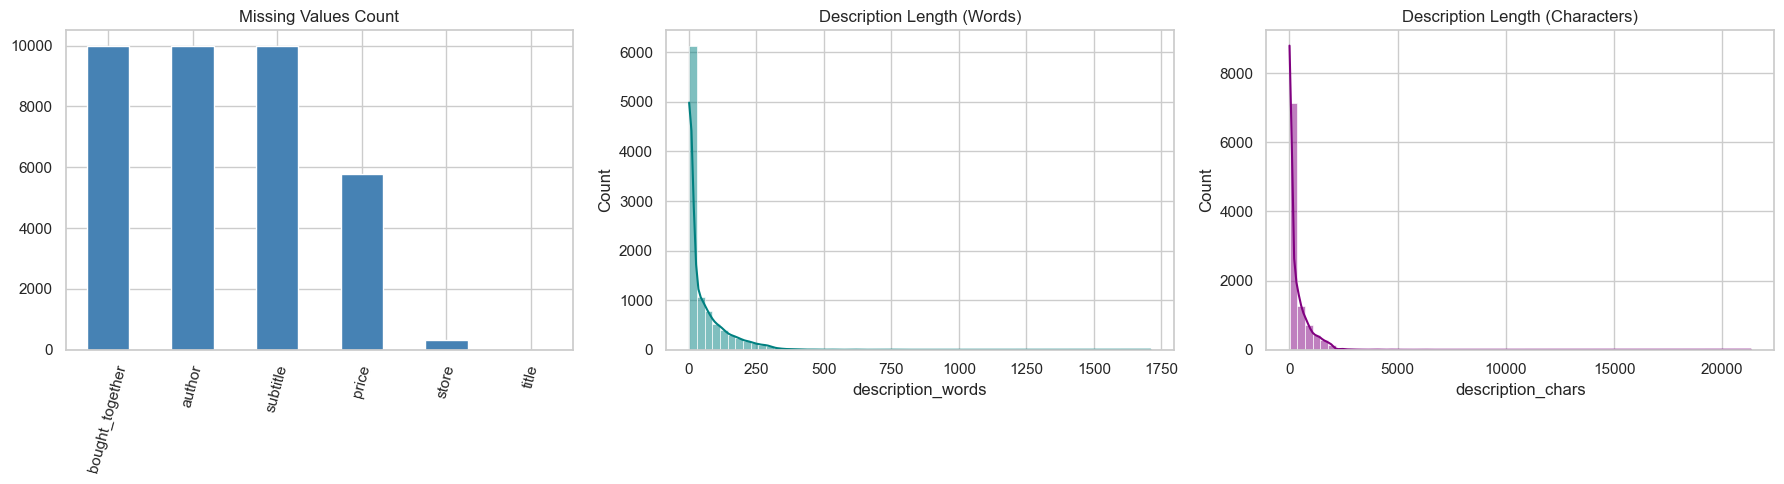

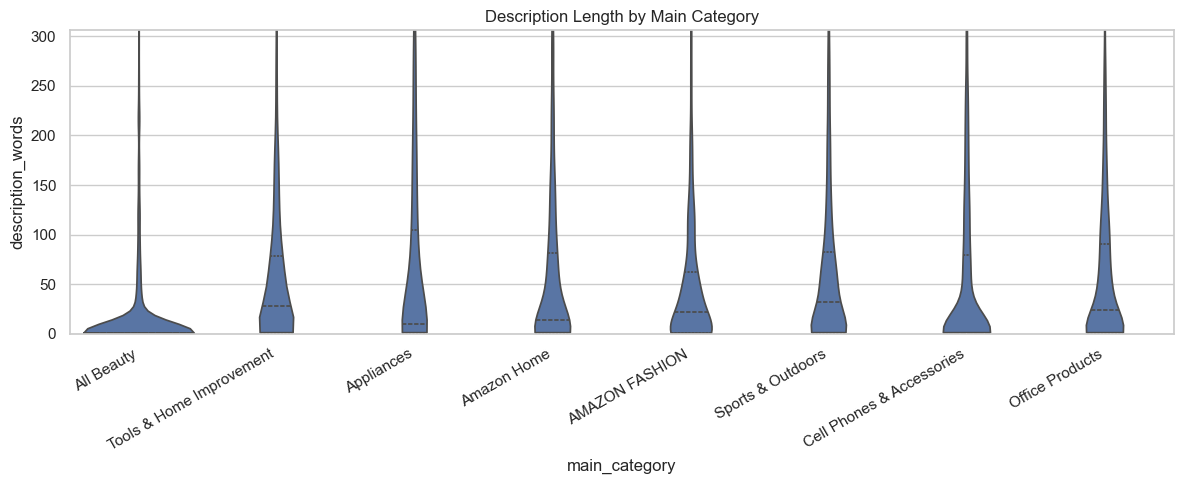

,description_words,description_chars,combined_words
count,10000.00000,10000.000000,10000.000000
mean,48.02980,311.446800,134.798700
std,80.65627,572.069902,130.982958
min,1.00000,2.000000,2.000000
50%,4.00000,29.000000,93.000000
90%,153.00000,988.100000,309.100000
95%,214.00000,1391.050000,388.050000
99%,308.00000,1967.000000,536.010000
max,1710.00000,21325.000000,1920.000000


In [17]:
eda_df = df_raw.copy()

missing = eda_df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

dup_rows = safe_duplicate_count(eda_df)
print("Potential duplicate rows (safe check):", dup_rows)

# ID integrity checks
if "doc_id" in eda_df.columns:
    print("doc_id unique:", int(eda_df["doc_id"].nunique()), "/", int(len(eda_df)))
    print("doc_id nulls:", int(eda_df["doc_id"].isna().sum()))

# Variant structure check (parent_asin is umbrella id)
if "parent_asin" in eda_df.columns:
    parent_counts = eda_df["parent_asin"].fillna("no_parent").astype(str).str.strip().replace("", "no_parent").value_counts()
    print("Unique parent_asin groups:", int(parent_counts.shape[0]))
    print("Avg variants per parent_asin:", round(float(parent_counts.mean()), 2))

eda_df["title_txt"] = eda_df.get("title", "").apply(to_text)
eda_df["description_txt"] = eda_df.get("description", "").apply(to_text)
eda_df["features_txt"] = eda_df.get("features", "").apply(to_text)
eda_df["combined_text"] = (eda_df["title_txt"] + " " + eda_df["description_txt"] + " " + eda_df["features_txt"]).str.strip()

eda_df["description_words"] = eda_df["description_txt"].apply(word_count)
eda_df["description_chars"] = eda_df["description_txt"].apply(char_count)
eda_df["combined_words"] = eda_df["combined_text"].apply(word_count)

# Field completeness profile
field_empty_profile = {
    "title_empty_pct": float((eda_df["title_txt"].str.strip() == "").mean() * 100),
    "description_empty_pct": float((eda_df["description_txt"].str.strip() == "").mean() * 100),
    "features_empty_pct": float((eda_df["features_txt"].str.strip() == "").mean() * 100),
    "combined_lt5_words_pct": float((eda_df["combined_words"] < 5).mean() * 100),
}
print(pd.Series(field_empty_profile).round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
if len(missing) > 0:
    missing.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Missing Values Count")
axes[0].tick_params(axis="x", rotation=75)

sns.histplot(eda_df["description_words"], bins=60, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Description Length (Words)")

sns.histplot(eda_df["description_chars"], bins=60, kde=True, ax=axes[2], color="purple")
axes[2].set_title("Description Length (Characters)")

plt.tight_layout()
plt.show()

top_cats = eda_df["main_category"].fillna("Unknown").value_counts().head(8).index
cat_df = eda_df[eda_df["main_category"].fillna("Unknown").isin(top_cats)].copy()
cat_df["main_category"] = cat_df["main_category"].fillna("Unknown")

plt.figure(figsize=(12, 5))
sns.violinplot(data=cat_df, x="main_category", y="description_words", inner="quartile", cut=0)
plt.xticks(rotation=30, ha="right")
plt.ylim(0, np.percentile(cat_df["description_words"], 99))
plt.title("Description Length by Main Category")
plt.tight_layout()
plt.show()

eda_df[["description_words", "description_chars", "combined_words"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

## Data Cleaning

In [18]:
df = df_raw.copy()

# Fill missing values for retrieval-relevant fields
for c in ["title", "description", "features", "main_category", "store"]:
    if c in df.columns:
        fill_value = "Unknown" if c == "main_category" else ""
        df[c] = df[c].fillna(fill_value)

# Normalize list-like fields to text
for c in ["description", "features", "categories"]:
    if c in df.columns:
        df[c] = df[c].apply(to_text)

# Build combined text now for quality filtering
df["combined_text"] = (df["title"].apply(to_text) + " " + df["description"] + " " + df["features"]).str.strip()

before_rows = len(df)

# Remove empty retrieval documents
df = df[df["combined_text"].str.strip() != ""].copy()

# Keep prepared doc_id from products.csv; only create fallback if missing
if "doc_id" not in df.columns:
    df = add_stable_doc_id(df)

# Only remove exact duplicated doc_id rows if they appear.
if "doc_id" in df.columns:
    df = df.drop_duplicates(subset=["doc_id"], keep="first")

df = df.reset_index(drop=True)

print(f"Rows before cleaning: {before_rows}")
print(f"Rows after cleaning: {len(df)}")
print("Unique doc_id:", df["doc_id"].nunique())

df.head(3)

Rows before cleaning: 10000
Rows after cleaning: 10000
Unique doc_id: 10000


,doc_num,doc_id,parent_asin,source_category_file,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,bought_together,subtitle,author,combined_text
0,1,B01CUPMQZE-NbrnTP3fAb,B01CUPMQZE,All Beauty,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,NaN,NaN,NaN,"Howard LC0008 Leather Conditioner, 8-Ounce (4-..."
1,2,B076WQZGPM-nFbmOHnKYa,B076WQZGPM,All Beauty,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",NaN,NaN,NaN,Yes to Tomatoes Detoxifying Charcoal Cleanser ...
2,3,B000B658RI-XRvj7uff0L,B000B658RI,All Beauty,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},NaN,NaN,NaN,Eye Patch Black Adult with Tie Band (6 Per Pac...


## Preprocessing

In [19]:
# Build lexical and semantic text variants

df["lexical_text"] = df["combined_text"].apply(clean_lexical_text)
# Keep semantic text relatively natural; only collapse excessive whitespace
df["semantic_text"] = df["combined_text"].apply(lambda t: re.sub(r"\s+", " ", to_text(t)).strip())

# Parse numeric analysis fields once (useful for diagnostics and later analysis)
for num_col in ["price", "rating_number", "average_rating"]:
    if num_col in df.columns:
        df[num_col] = pd.to_numeric(df[num_col], errors="coerce")

pre_rows = len(df)

# Safety filter: keep records with usable lexical and semantic content
df = df[(df["lexical_text"].str.strip() != "") & (df["semantic_text"].str.strip() != "")].reset_index(drop=True)

# Keep id arrays for retrieval wrappers
idx_to_doc_id = df["doc_id"].to_numpy()
doc_id_set = set(idx_to_doc_id)

print("Preprocessing stats")
print("- rows before:", pre_rows)
print("- rows after:", len(df))
print("- pct dropped:", round((1 - len(df) / pre_rows) * 100, 2) if pre_rows else 0)
print("- avg lexical words:", round(df["lexical_text"].str.split().str.len().mean(), 2))
print("- avg semantic words:", round(df["semantic_text"].str.split().str.len().mean(), 2))

print(df[["doc_id", "title", "main_category", "lexical_text"]].head(2))

Preprocessing stats
- rows before: 10000
- rows after: 9998
- pct dropped: 0.02
- avg lexical words: 139.56
- avg semantic words: 134.83
                  doc_id                                              title  \
0  B01CUPMQZE-NbrnTP3fAb  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1  B076WQZGPM-nFbmOHnKYa  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   

  main_category                                       lexical_text  
0    All Beauty   howard lc0008 leather conditioner 8 ounce 4 pack  
1    All Beauty  yes to tomatoes detoxifying charcoal cleanser ...  


In [8]:
# BM25
bm25_corpus = [doc.split() for doc in df["lexical_text"].tolist()]
bm25 = BM25Okapi(bm25_corpus)

print("BM25 docs:", len(bm25_corpus))

BM25 docs: 9998


In [9]:
# SBERT embeddings + index
sbert_model_name = "all-MiniLM-L6-v2"
sbert_model = SentenceTransformer(sbert_model_name)
sbert_embeddings = sbert_model.encode(df["semantic_text"].tolist(), show_progress_bar=True, batch_size=64)
sbert_embeddings = np.asarray(sbert_embeddings, dtype=np.float32)

sbert_index = faiss.IndexFlatL2(sbert_embeddings.shape[1])
sbert_index.add(sbert_embeddings)

print("SBERT index size:", sbert_index.ntotal)

Batches: 100%|██████████| 157/157 [00:22<00:00,  6.93it/s]

SBERT index size: 9998


In [10]:
# E5 embeddings + index
e5_model_name = "intfloat/e5-base"
e5_model = SentenceTransformer(e5_model_name)
e5_passages = ["passage: " + t for t in df["semantic_text"].tolist()]
e5_embeddings = e5_model.encode(e5_passages, show_progress_bar=True, batch_size=64)
e5_embeddings = np.asarray(e5_embeddings, dtype=np.float32)

e5_index = faiss.IndexFlatL2(e5_embeddings.shape[1])
e5_index.add(e5_embeddings)
print("E5 index size:", e5_index.ntotal)

Batches: 100%|██████████| 157/157 [02:33<00:00,  1.02it/s]

E5 index size: 9998


## Evaluation

In [11]:
# Retrieval wrappers + ranking fusion
def bm25_retrieve(query, top_k=10):
    tokens = clean_lexical_text(query).split()
    scores = np.asarray(bm25.get_scores(tokens), dtype=np.float32)
    k = min(top_k, len(scores))
    if k == 0:
        return []
    idx = np.argpartition(-scores, kth=k - 1)[:k]
    idx = idx[np.argsort(-scores[idx])]
    return [(idx_to_doc_id[i], float(scores[i])) for i in idx]


def sbert_retrieve(query, top_k=10):
    q = np.asarray(sbert_model.encode([to_text(query)]), dtype=np.float32)
    distances, indices = sbert_index.search(q, top_k)
    out = []
    for d, i in zip(distances[0], indices[0]):
        if i != -1:
            out.append((idx_to_doc_id[i], float(-d)))
    return out


def e5_retrieve(query, top_k=10):
    q = np.asarray(e5_model.encode(["query: " + to_text(query)]), dtype=np.float32)
    distances, indices = e5_index.search(q, top_k)
    out = []
    for d, i in zip(distances[0], indices[0]):
        if i != -1:
            out.append((idx_to_doc_id[i], float(-d)))
    return out


def rrf_hybrid_retrieve(query, top_k=10, pool_k=100, k0=60):
    bm = bm25_retrieve(query, top_k=pool_k)
    e5 = e5_retrieve(query, top_k=pool_k)

    scores = defaultdict(float)
    for rank, (doc_id, _) in enumerate(bm, start=1):
        scores[doc_id] += 1.0 / (k0 + rank)
    for rank, (doc_id, _) in enumerate(e5, start=1):
        scores[doc_id] += 1.0 / (k0 + rank)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return ranked

In [12]:
# Benchmark loading and metric functions
# Required files:
# benchmark/queries.csv -> query_id,query_text
# benchmark/qrels.csv   -> query_id,doc_id,relevance

queries_path = os.path.join(BENCHMARK_DIR, "queries.csv")
qrels_path = os.path.join(BENCHMARK_DIR, "qrels.csv")

if not (os.path.exists(queries_path) and os.path.exists(qrels_path)):
    raise FileNotFoundError(
        "Create benchmark/queries.csv and benchmark/qrels.csv before evaluation."
    )

queries_df = pd.read_csv(queries_path)
qrels_df = pd.read_csv(qrels_path)

queries_df["query_id"] = queries_df["query_id"].astype(str)
qrels_df["query_id"] = qrels_df["query_id"].astype(str)
qrels_df["doc_id"] = qrels_df["doc_id"].astype(str)
qrels_df["relevance"] = qrels_df["relevance"].astype(float)

# keep only qrels that exist in current corpus
qrels_df = qrels_df[qrels_df["doc_id"].isin(doc_id_set)].copy()


def build_rel_judgements(qrels):
    rel = defaultdict(dict)
    for r in qrels.itertuples(index=False):
        rel[r.query_id][r.doc_id] = float(r.relevance)
    return rel


def precision_at_k(ranked_ids, rel_map, k=10, rel_threshold=1):
    ranked = ranked_ids[:k]
    denom = min(k, len(ranked_ids))
    if denom == 0:
        return 0.0
    hits = sum(1 for d in ranked if rel_map.get(d, 0) >= rel_threshold)
    return hits / denom


def recall_at_k(ranked_ids, rel_map, k=10, rel_threshold=1):
    total_rel = sum(1 for _, r in rel_map.items() if r >= rel_threshold)
    if total_rel == 0:
        return 0.0
    hits = sum(1 for d in ranked_ids[:k] if rel_map.get(d, 0) >= rel_threshold)
    return hits / total_rel


def reciprocal_rank_at_k(ranked_ids, rel_map, k=10, rel_threshold=1):
    for rank, d in enumerate(ranked_ids[:k], start=1):
        if rel_map.get(d, 0) >= rel_threshold:
            return 1.0 / rank
    return 0.0


def average_precision_at_k(ranked_ids, rel_map, k=10, rel_threshold=1):
    ranked = ranked_ids[:k]
    total_rel = sum(1 for _, r in rel_map.items() if r >= rel_threshold)
    if total_rel == 0:
        return 0.0

    hit_count = 0
    precision_sum = 0.0
    for i, d in enumerate(ranked, start=1):
        if rel_map.get(d, 0) >= rel_threshold:
            hit_count += 1
            precision_sum += hit_count / i
    return precision_sum / min(total_rel, k)


def ndcg_at_k(ranked_ids, rel_map, k=10):
    gains = np.array([rel_map.get(d, 0.0) for d in ranked_ids[:k]], dtype=np.float32)
    discounts = 1.0 / np.log2(np.arange(2, len(gains) + 2))
    dcg = float(np.sum(gains * discounts))

    ideal = np.array(sorted(rel_map.values(), reverse=True)[:k], dtype=np.float32)
    ideal_discounts = 1.0 / np.log2(np.arange(2, len(ideal) + 2))
    idcg = float(np.sum(ideal * ideal_discounts))
    return 0.0 if idcg == 0 else dcg / idcg


print("Queries:", len(queries_df), "| Qrels:", len(qrels_df))
queries_df.head(3)

Queries: 100 | Qrels: 0


,query_id,query_text,intent,primary_category,difficulty
0,Q001,acne face cleanser for oily skin,feature-based,All Beauty,easy
1,Q002,matte foundation for dark skin tone,feature-based,All Beauty,medium
2,Q003,sulfate free baby shampoo,feature-based,All Beauty,easy


In [13]:
# Build candidate pool for manual relevance scoring (qrels)
# Creates one row per (query_id, doc_id) from the union of top-k per model.
# Only builds when a candidate pool file does not already exist.

CANDIDATE_TOP_K = 10
candidate_pool_path = os.path.join(BENCHMARK_DIR, "candidate_pool_for_labeling.csv")

if os.path.exists(candidate_pool_path):
    print(f"Candidate pool already exists: {candidate_pool_path}")
    candidate_pool = pd.read_csv(candidate_pool_path)
else:
    keep_cols = [c for c in ["doc_num", "title", "main_category"] if c in df.columns]
    candidate_rows = []

    for q in queries_df.itertuples(index=False):
        qid = str(q.query_id)
        qtext = q.query_text

        bm25_ids = [doc_id for doc_id, _ in bm25_retrieve(qtext, top_k=CANDIDATE_TOP_K)]
        sbert_ids = [doc_id for doc_id, _ in sbert_retrieve(qtext, top_k=CANDIDATE_TOP_K)]
        e5_ids = [doc_id for doc_id, _ in e5_retrieve(qtext, top_k=CANDIDATE_TOP_K)]
        hybrid_ids = [doc_id for doc_id, _ in rrf_hybrid_retrieve(qtext, top_k=CANDIDATE_TOP_K)]

        # Ordered union: keep first-seen order while deduplicating
        union_ids = list(dict.fromkeys(bm25_ids + sbert_ids + e5_ids + hybrid_ids))

        for did in union_ids:
            row = df.loc[df["doc_id"] == did, keep_cols].iloc[0]
            candidate_rows.append({
                "query_id": qid,
                "query_text": qtext,
                "doc_num": row["doc_num"] if "doc_num" in row else "",
                "doc_id": did,
                "title": row["title"],
                "main_category": row["main_category"],
                "relevance": "",  # fill manually: 0, 1, or 2
                "notes": "",
            })

    candidate_pool = pd.DataFrame(candidate_rows)
    candidate_pool.to_csv(candidate_pool_path, index=False)
    print(f"Candidate pool created: {candidate_pool_path}")

print("Rows:", len(candidate_pool))
print("Avg candidates/query:", round(len(candidate_pool) / len(queries_df), 2))

candidate_pool.head(15)

Candidate pool saved: benchmark/candidate_pool_for_labeling.csv
Rows: 2082
Avg candidates/query: 20.82


,query_id,query_text,doc_num,doc_id,title,main_category,relevance,notes
0,Q001,acne face cleanser for oily skin,556,B07G9QDLHR-2jJ5ciOD4c,"Hydrating Peel Off Glitter Face Mask, Moisturi...",All Beauty,,
1,Q001,acne face cleanser for oily skin,353,B0182Y1IUG-MsFmP6wdnC,Healing Clay Mud Mask for Deep Pore Cleansing ...,All Beauty,,
2,Q001,acne face cleanser for oily skin,241,B07HPC9TLX-YRsMfihslQ,Buffing Granules Daily Exfoliating Cleanser - ...,All Beauty,,
3,Q001,acne face cleanser for oily skin,478,B00WEN2SXS-j3Ofx7LMoo,"Tea Tree Facial Cleanser, Pure Mauve Invigorat...",All Beauty,,
4,Q001,acne face cleanser for oily skin,963,B01KB8R3NW-Q0K8KEpgYJ,Stone Crop Gel Facial Cleanser by Eva Naturals...,All Beauty,,
5,Q001,acne face cleanser for oily skin,132,B07PV3R2Y4-ln6Eoie0gV,Organic Face Wash Bar Soap - Facial Cleanser S...,All Beauty,,
6,Q001,acne face cleanser for oily skin,1204,B071F78NNF-C9qXmVHtyv,"Almay Clear Complexion Pressed Powder, Hypoall...",All Beauty,,
7,Q001,acne face cleanser for oily skin,358,B01MZ4IMKE-50DF5kJThy,1Set(5PCS) Portable Professional Stainless Ste...,All Beauty,,
8,Q001,acne face cleanser for oily skin,1980,B098Q4SS34-LVI0qPbXQw,Triple Seven Grooming: Bamboo Charcoal Mask - ...,All Beauty,,
9,Q001,acne face cleanser for oily skin,323,B07C1M5KRZ-pCPZygFP0x,"Oil Blotting Sheets, Teenitor Natural Blotting...",All Beauty,,


In [16]:
def evaluate_system(name, retrieve_fn, queries, qrels):
    rel = build_rel_judgements(qrels)
    rows = []
    latency_ms = []

    for q in queries.itertuples(index=False):
        qid = str(q.query_id)
        qtext = q.query_text
        if qid not in rel:
            continue

        t0 = time.perf_counter()
        # Retrieve top-10 once, then compute both @5 and @10 from that ranking.
        ranked = retrieve_fn(qtext, top_k=10)
        latency_ms.append((time.perf_counter() - t0) * 1000)

        ranked_ids = [doc_id for doc_id, _ in ranked]
        rel_map = rel[qid]

        rows.append({
            "system": name,
            "query_id": qid,
            "p@5": precision_at_k(ranked_ids, rel_map, 5),
            "recall@5": recall_at_k(ranked_ids, rel_map, 5),
            "mrr@5": reciprocal_rank_at_k(ranked_ids, rel_map, 5),
            "map@5": average_precision_at_k(ranked_ids, rel_map, 5),
            "ndcg@5": ndcg_at_k(ranked_ids, rel_map, 5),
            "p@10": precision_at_k(ranked_ids, rel_map, 10),
            "recall@10": recall_at_k(ranked_ids, rel_map, 10),
            "mrr@10": reciprocal_rank_at_k(ranked_ids, rel_map, 10),
            "map@10": average_precision_at_k(ranked_ids, rel_map, 10),
            "ndcg@10": ndcg_at_k(ranked_ids, rel_map, 10),
            "latency_ms": latency_ms[-1],
        })

    per_query = pd.DataFrame(rows)
    if per_query.empty:
        raise ValueError("No evaluated rows. Check qrels coverage and doc_id alignment.")
    summary = per_query.drop(columns=["system", "query_id"]).mean().to_frame(name=name).T
    return per_query, summary


bm25_perq, bm25_summary = evaluate_system("BM25", bm25_retrieve, queries_df, qrels_df)
sbert_perq, sbert_summary = evaluate_system("SBERT", sbert_retrieve, queries_df, qrels_df)
e5_perq, e5_summary = evaluate_system("E5", e5_retrieve, queries_df, qrels_df)
hybrid_perq, hybrid_summary = evaluate_system("Hybrid_RRF_BM25_E5", rrf_hybrid_retrieve, queries_df, qrels_df)

summary = pd.concat([bm25_summary, sbert_summary, e5_summary, hybrid_summary], axis=0).reset_index(drop=True)
summary

ValueError: No evaluated rows. Check qrels coverage and doc_id alignment.

## Results & Analysis

In [ ]:
# Aggregate metric view
metric_cols = ["p@5", "recall@5", "mrr@5", "map@5", "ndcg@5", "p@10", "recall@10", "mrr@10", "map@10", "ndcg@10", "latency_ms"]

display(summary[metric_cols].style.format({c: "{:.4f}" for c in metric_cols if c != "latency_ms"}).format({"latency_ms": "{:.2f}"}))

# Plot ranking quality metrics
plot_metrics = ["p@5", "recall@5", "mrr@5", "map@5", "ndcg@5", "p@10", "recall@10", "mrr@10", "map@10", "ndcg@10"]
ax = summary.set_index(pd.Index(["BM25", "SBERT", "E5", "Hybrid_RRF_BM25_E5"]))[plot_metrics].plot(
    kind="bar", figsize=(10, 5), rot=15
)
ax.set_title("System Comparison on Retrieval Metrics")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

# Best model by nDCG@10
names = ["BM25", "SBERT", "E5", "Hybrid_RRF_BM25_E5"]
summary_named = summary.copy()
summary_named["system"] = names
best_row = summary_named.sort_values("ndcg@10", ascending=False).iloc[0]
print("Best system by nDCG@10:", best_row["system"])
print(best_row[["ndcg@10", "mrr@10", "recall@10", "latency_ms"]])

In [ ]:
# Per-query win/loss analysis + export artifacts
merged = bm25_perq[["query_id", "ndcg@10"]].rename(columns={"ndcg@10": "bm25_ndcg"})
merged = merged.merge(sbert_perq[["query_id", "ndcg@10"]].rename(columns={"ndcg@10": "sbert_ndcg"}), on="query_id", how="outer")
merged = merged.merge(e5_perq[["query_id", "ndcg@10"]].rename(columns={"ndcg@10": "e5_ndcg"}), on="query_id", how="outer")
merged = merged.merge(hybrid_perq[["query_id", "ndcg@10"]].rename(columns={"ndcg@10": "hybrid_ndcg"}), on="query_id", how="outer")

merged = merged.fillna(0)
merged["winner"] = merged[["bm25_ndcg", "sbert_ndcg", "e5_ndcg", "hybrid_ndcg"]].idxmax(axis=1)
print("Winner counts by query:")
print(merged["winner"].value_counts())

# Save core artifacts for dissertation appendix
os.makedirs(BENCHMARK_DIR, exist_ok=True)
os.makedirs(MODEL_ARTIFACT_DIR, exist_ok=True)

df.to_csv(os.path.join(MODEL_ARTIFACT_DIR, "final_dataset.csv"), index=False)
np.save(os.path.join(MODEL_ARTIFACT_DIR, "sbert_embeddings.npy"), sbert_embeddings)
np.save(os.path.join(MODEL_ARTIFACT_DIR, "e5_embeddings.npy"), e5_embeddings)
summary_named.to_csv(os.path.join(BENCHMARK_DIR, "results_summary.csv"), index=False)

all_per_query = pd.concat([bm25_perq, sbert_perq, e5_perq, hybrid_perq], axis=0, ignore_index=True)
all_per_query.to_csv(os.path.join(BENCHMARK_DIR, "results_per_query.csv"), index=False)

print("Saved artifacts to:")
print("-", MODEL_ARTIFACT_DIR)
print("-", BENCHMARK_DIR)